# Module 17 — A/B Testing, ANOVA & Statistical Power

This is how data scientists prove **causation**, not just correlation — the work
that drives real product decisions ("did the new button actually increase signups,
or did we just get lucky?"). It's a favourite interview topic at product companies.

**What you'll be able to do by the end:**
- Explain *why* a randomized experiment licenses a causal claim.
- Design an A/B test up front: hypotheses, one metric, and a **power analysis** for
  sample size.
- Analyze results with a **z-test** (proportions) or **t-test** (means).
- Use **ANOVA** to compare **3+** groups — and say why you can't just run many t-tests.
- Name the classic traps: Type I/II errors, peeking, multiple comparisons.

> 🌱 **In plain English**
>
> An A/B test is a **fair coin flip for your users**. Split them randomly into two
> groups: group A sees the old version, group B sees the new one. Because the split is
> random, the two groups are basically identical *except* for the one thing you
> changed. So if group B behaves differently, it's the *change* that caused it — not
> some hidden difference between the people.
>
> The rest of the module is about doing that flip carefully and reading the result
> honestly, so you don't fool yourself.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_theme(style="whitegrid")
rng = np.random.default_rng(42)
print("Tools ready.")

Tools ready.


## 17.1 Why A/B testing gives causation

> 🧠 **Analogy** — Imagine testing whether a fertilizer helps plants. If you give it only to the plants
on the sunny windowsill, you'll never know if it was the fertilizer or the sun.
**Randomly** assigning fertilizer across all plants makes the sunny/shady mix roughly
equal in both groups — so any difference in growth is down to the fertilizer.
Random assignment is what "cancels out" every hidden factor.

> 🎓 **Go deeper**
>
> Back in EDA we said correlation isn't causation because of **confounders** — lurking
> variables that drive both things. Random assignment breaks confounding: on average the
> control and treatment groups are equivalent in *every* respect (age, device, mood,
> day of week) except the one change you made. That equivalence is exactly what lets you
> attribute an outcome difference **to the change**. Observational data can't promise
> this, which is why experiments are the gold standard for causal claims.

> 📖 **Control (A)** = the group that sees the current/unchanged version

> 📖 **Treatment / Variant (B)** = the group that sees the new version you're testing

> 📖 **Confounder** = a hidden factor that affects both the treatment and the outcome, faking a causal link

> ✅ **Takeaway** — Random assignment makes groups equivalent on average, so an outcome difference can be blamed on the change -> causation.

## 17.2 Design FIRST — hypotheses, metric, and sample size

The single biggest mistake beginners make is running the test and *then* deciding
what counts as success. Everything below is decided **before** you collect one data
point.

> 🌱 **In plain English**
>
> Before launching, pin down five things:
> 1. **Hypotheses** — H0: "no difference"; H1: "B differs from A".
> 2. **One primary metric** — e.g. signup rate. Just one, so you're not fishing.
> 3. **α (alpha)** — how often you'll tolerate a false alarm (usually 5%).
> 4. **Power** — how often you want to catch a real effect (usually 80%).
> 5. **How big an effect you care about** (the smallest lift worth shipping).
>
> From those, a **power analysis** tells you how many users you need per group. Decide
> it now; don't peek and stop early.

> 📖 **Null hypothesis (H0)** = the boring default: 'there is no real difference'

> 📖 **MDE (Minimum Detectable Effect)** = the smallest improvement you'd actually care about detecting

> 📖 **Power** = the chance your test detects a real effect when one truly exists (usually aim for 0.80)

In [2]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

baseline = 0.10           # current conversion 10%
target   = 0.12           # we want to detect a lift to 12% (MDE = 2 points)
effect = proportion_effectsize(target, baseline)   # standardized effect size (Cohen's h)

analysis = NormalIndPower()
n_per_group = analysis.solve_power(effect_size=effect, alpha=0.05, power=0.80,
                                   alternative="two-sided")
print(f"standardized effect size (Cohen's h) = {effect:.3f}")
print(f"required sample size PER GROUP ~ {int(np.ceil(n_per_group)):,}")
print("Run until each arm reaches this size - decided IN ADVANCE.")

standardized effect size (Cohen's h) = 0.064
required sample size PER GROUP ~ 3,835
Run until each arm reaches this size - decided IN ADVANCE.


> 🔤 **Reading the code (line by line)**
>
> - `proportion_effectsize(0.12, 0.10)` converts "10% -> 12%" into a standardized
>   "effect size" — a unit the math needs.
> - `solve_power(...)` answers: given that effect, a 5% false-alarm rate, and a wish to
>   catch it 80% of the time, **how many users per group?**
> - The printed number (~a few thousand) is your finish line. You commit to it now.

> ⚠️ **Watch out** — Stopping the moment you "see significance" (**peeking**) massively inflates false
positives — check often enough and random noise *will* cross p<0.05 by chance.
Committing to a sample size up front is the discipline that keeps A/B tests honest.

> ✅ **Takeaway** — Do a power analysis BEFORE the test to fix the sample size; never stop early just because it looks significant.

## 17.3 Analyze a proportions A/B test (z-test)

When the metric is a **rate** (converted: yes/no), we compare two proportions with a
**z-test**. We simulate a test where B truly converts a bit better, then analyze it
the way you'd analyze real logs.

In [3]:
n = 3000
conv_A = rng.random(n) < 0.10        # control: true 10%
conv_B = rng.random(n) < 0.12        # treatment: true 12%

from statsmodels.stats.proportion import proportions_ztest
successes = [conv_B.sum(), conv_A.sum()]
nobs = [n, n]
z, p = proportions_ztest(successes, nobs, alternative="larger")   # is B > A?

rate_A, rate_B = conv_A.mean(), conv_B.mean()
print(f"A (control)   conversion: {rate_A:.3%}")
print(f"B (treatment) conversion: {rate_B:.3%}")
print(f"absolute lift: {rate_B - rate_A:+.3%} | relative: {(rate_B/rate_A - 1):+.1%}")
print(f"z = {z:.3f}, p = {p:.4f}")
print("Decision:", "ship B - significant improvement" if p < 0.05
      else "not significant - keep A / gather more data")

A (control)   conversion: 9.800%
B (treatment) conversion: 12.067%
absolute lift: +2.267% | relative: +23.1%
z = 2.813, p = 0.0025
Decision: ship B - significant improvement


> 🔤 **Reading the code (line by line)**
>
> - We fake 3,000 users per arm; A converts ~10%, B ~12%.
> - `proportions_ztest` asks "is B's rate significantly *larger* than A's?" and returns
>   a z-score and a p-value.
> - p < 0.05 -> the lift is unlikely to be pure chance -> ship B.
> - Notice we print the **lift** too: significance says "it's real"; the lift says
>   "is it *big enough to bother*". Both matter.

> 🗣️ **Say this in an interview** — "I always report the effect size alongside the p-value. A statistically significant
0.1% lift might not be worth the engineering cost — significance and business impact
are two different questions, and the analysis should inform both."

> ✅ **Takeaway** — Rate metrics -> two-proportion z-test; report the lift, not just the p-value.

## 17.4 Comparing means (t-test) — e.g. time-on-page

If the metric is a **mean** (revenue per user, seconds on page), use a **t-test**.

In [4]:
time_A = rng.normal(50, 15, 500)     # seconds on page, control
time_B = rng.normal(54, 15, 500)     # treatment slightly higher
t, p = stats.ttest_ind(time_B, time_A, equal_var=False)  # Welch's t-test
print(f"mean time A={time_A.mean():.1f}s, B={time_B.mean():.1f}s")
print(f"t = {t:.3f}, p = {p:.4f} ->",
      "significant" if p < 0.05 else "not significant")

mean time A=50.8s, B=54.2s
t = 3.452, p = 0.0006 -> significant


### ✏️ Worked example (by hand): a tiny two-sample t-test

The formula looks scary, so let's compute one on 3 numbers per group where you can
see every step.

**Group A** = [4, 6, 8], **Group B** = [7, 9, 11].

**Step 1 — means:**
$\bar{A} = \frac{4+6+8}{3} = 6$, $\bar{B} = \frac{7+9+11}{3} = 9$.

**Step 2 — sample variances** (divide by n−1 = 2). Both groups have deviations of
−2, 0, +2, so squared deviations sum to $4+0+4 = 8$:
$s_A^2 = s_B^2 = \frac{8}{2} = 4$.

**Step 3 — standard error of the difference** (equal-size groups):
$SE = \sqrt{\frac{s_A^2}{n} + \frac{s_B^2}{n}} = \sqrt{\frac{4}{3}+\frac{4}{3}}
= \sqrt{2.667} \approx 1.633$.

**Step 4 — t statistic:**
$t = \dfrac{\bar{B}-\bar{A}}{SE} = \dfrac{9-6}{1.633} \approx 1.837$.

A t of ~1.84 on so few points isn't significant, but the *mechanics* are the whole
point: **(difference in means) ÷ (noise in that difference)**. Big signal, small
noise -> big t -> small p.

In [5]:
A = np.array([4, 6, 8]); B = np.array([7, 9, 11])
mean_A, mean_B = A.mean(), B.mean()
varA, varB = A.var(ddof=1), B.var(ddof=1)          # ddof=1 -> divide by n-1
se = np.sqrt(varA/len(A) + varB/len(B))
t_byhand = (mean_B - mean_A) / se
print(f"means: A={mean_A}, B={mean_B}")
print(f"variances: sA^2={varA}, sB^2={varB}")
print(f"SE = {se:.3f}")
print(f"t (by hand) = {t_byhand:.3f}")

# Confirm against scipy
t_scipy, p_scipy = stats.ttest_ind(B, A, equal_var=True)
print(f"t (scipy)   = {t_scipy:.3f}   MATCH: {np.isclose(t_byhand, t_scipy)}")

means: A=6.0, B=9.0
variances: sA^2=4.0, sB^2=4.0
SE = 1.633
t (by hand) = 1.837
t (scipy)   = 1.837   MATCH: True


> ✅ **Takeaway** — A t-statistic is signal (difference in means) divided by noise (its standard error): big t -> small p.

## 17.5 ANOVA — comparing 3+ groups the right way

Testing **three** landing pages (A/B/C)? Don't run three separate t-tests.

> 🌱 **In plain English**
>
> Every test has a 5% chance of a false alarm. Run three of them and the chance that
> *at least one* fires by luck climbs well above 5% — that's the **multiple-comparisons
> problem**. ANOVA sidesteps it by asking one combined question: "are all the group
> means the same, yes or no?" — a single test, one error rate.

> 🧠 **Analogy** — ANOVA compares **the spread *between* groups** to **the spread *within* each group**.
If three choirs each sing steadily but at clearly different pitches, the
between-choir spread dwarfs the within-choir wobble — you can tell they differ. If
every choir is all over the place, the between-group gap is lost in the noise. That
ratio is the **F-statistic**: big F -> groups really differ.

> 📖 **ANOVA** = Analysis of Variance — one test for 'are 3+ group means all equal?'

> 📖 **F-statistic** = ratio of between-group variance to within-group variance; big F means the groups differ

> 📖 **Multiple-comparisons problem** = running many tests inflates the chance at least one is a false positive

In [6]:
page_A = rng.normal(50, 12, 300)
page_B = rng.normal(52, 12, 300)
page_C = rng.normal(57, 12, 300)     # C is genuinely better

f_stat, p_anova = stats.f_oneway(page_A, page_B, page_C)
print(f"ANOVA F = {f_stat:.3f}, p = {p_anova:.4g}")
print("Interpretation:", "at least one page differs" if p_anova < 0.05
      else "no evidence of any difference")

ANOVA F = 15.952, p = 1.558e-07
Interpretation: at least one page differs


ANOVA tells you *that* a difference exists, not *which* pair differs. For that, run a
**post-hoc** test (e.g. Tukey's HSD) that corrects for the multiple comparisons.

In [7]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
vals = np.concatenate([page_A, page_B, page_C])
grp = (["A"]*300) + (["B"]*300) + (["C"]*300)
tukey = pairwise_tukeyhsd(vals, grp, alpha=0.05)
print(tukey)
print("\n'reject=True' rows are the pairs that significantly differ.")

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B   0.7995 0.6775 -1.4319 3.0309  False
     A      C   4.9974    0.0   2.766 7.2289   True
     B      C   4.1979    0.0  1.9665 6.4293   True
---------------------------------------------------

'reject=True' rows are the pairs that significantly differ.


> 🔤 **Reading the code (line by line)**
>
> - `f_oneway` runs the single ANOVA F-test across all three pages at once.
> - A small p means "at least one page's mean is different" — but not which.
> - `pairwise_tukeyhsd` then compares each pair (A-B, A-C, B-C) *with a correction* so
>   the overall false-positive rate stays at 5%. Rows marked `reject=True` are the
>   genuinely different pairs (here, the ones involving the better page C).

> ✅ **Takeaway** — 3+ groups -> one ANOVA F-test (not many t-tests); if significant, use Tukey post-hoc to find which pairs differ.

## 17.6 Power, errors, and honesty

> 🌱 **In plain English**
>
> Two ways a test can be wrong:
> - **Type I error (false positive)** — you shout "it works!" when it doesn't. Its rate
>   is α (usually 5%).
> - **Type II error (false negative)** — you miss a real improvement.
> **Power** = the chance you *catch* a real effect. It grows with a bigger sample, a
> bigger true effect, and a looser α. Below we watch power climb as the sample grows.

> 📖 **Type I error** = a false positive: declaring an effect that isn't real (rate = alpha)

> 📖 **Type II error** = a false negative: missing an effect that is real (rate = beta)

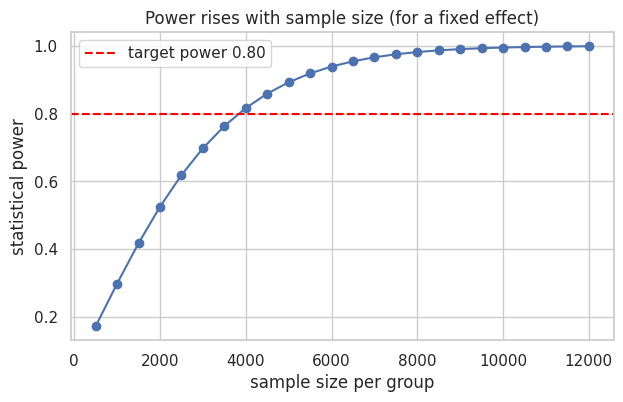

In [8]:
sizes = np.arange(500, 12001, 500)
powers = [NormalIndPower().solve_power(effect_size=effect, nobs1=nn,
                                       alpha=0.05, alternative="two-sided")
          for nn in sizes]
plt.figure(figsize=(7,4))
plt.plot(sizes, powers, "o-")
plt.axhline(0.80, color="red", ls="--", label="target power 0.80")
plt.xlabel("sample size per group"); plt.ylabel("statistical power")
plt.title("Power rises with sample size (for a fixed effect)"); plt.legend(); plt.show()

> ⚠️ **Watch out** — **Traps interviewers love:**
- **Peeking / early stopping** — checking repeatedly inflates false positives; fix the
  sample size up front.
- **Multiple comparisons** — many metrics/variants means some look "significant" by
  luck; correct (Bonferroni/FDR) or pre-register one primary metric.
- **Novelty & seasonality** — run long enough to be representative.
- **Sample ratio mismatch** — if the split isn't ~50/50, your randomization or
  logging is broken; investigate before trusting anything.

> 🗣️ **Say this in an interview** — "Power is the probability of detecting a true effect. If a test came back null but was
underpowered, I don't conclude 'no effect' — I conclude 'not enough data to tell'.
That distinction saves teams from killing good features prematurely."

## 17.7 Practice

> ✍️ **Try this yourself** — 1. Recompute the required sample size for a 10% -> 11% lift. Why is it so much larger?
2. Simulate an A/B test where A and B are *identical*; run it 1000x and confirm ~5% of
   runs give p<0.05 (that's alpha in action).
3. Run ANOVA where all three groups are identical — what p-value do you expect?
4. Explain to a PM in one sentence why you shouldn't stop the test the moment it hits
   p<0.05.

## Summary

- **Randomization** -> causal claims (the whole point of A/B testing).
- **Design first**: hypotheses, one metric, α, power, MDE -> **power analysis** for
  sample size.
- Analyze with a **z-test** (proportions) or **t-test** (means); always report the
  **effect size**. A t-stat is signal ÷ noise.
- **ANOVA** compares 3+ groups in one F-test (avoids multiple-comparison inflation);
  follow with **Tukey** post-hoc to find which pairs differ.
- Mind **power**, **Type I/II errors**, and the **peeking / multiple-comparisons**
  traps.

Next: **Module 18 — OOP + Linear Algebra & Calculus for ML**.